# Graficos Educación

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("modulo_educacion.csv")
df.head()

,id_hogar,region,estrato,jefe_hogar,alfabetismo,nivel_educacion
0,100020301,13,1312712,1.0,1.0,9
1,100020301,13,1312712,0.0,1.0,7
2,100020401,13,1312712,1.0,1.0,7
3,100020401,13,1312712,0.0,1.0,7
4,100020401,13,1312712,0.0,1.0,12


In [8]:
# filtrar solo region de los rios
df_losrios = df[df["region"] == 14]

# Filtrar solo jefes de hogar 
df_jefes = df_losrios[df_losrios["jefe_hogar"] == 1.0]
# Mapear códigos a etiquetas 
etiquetas_e6a = {
    1: "Nunca asistió",
    2: "Sala cuna",
    3: "Jardín infantil",
    4: "Prekínder/Kínder",
    5: "Ed. especial",
    6: "Primaria antigua",
    7: "Ed. básica",
    8: "Humanidades",
    9: "Media C-H",
    10: "Media T-P antigua",
    11: "Media T-P",
    12: "Técnico superior",
    13: "Universitaria",
    14: "Magíster",
    15: "Doctorado"
}
# Cuenta cada valor y ordena <
conteo = df_jefes["nivel_educacion"].value_counts().sort_values()

# Mapea el valor con su correspondiente etiqueta
conteo.index = conteo.index.map(etiquetas_e6a)



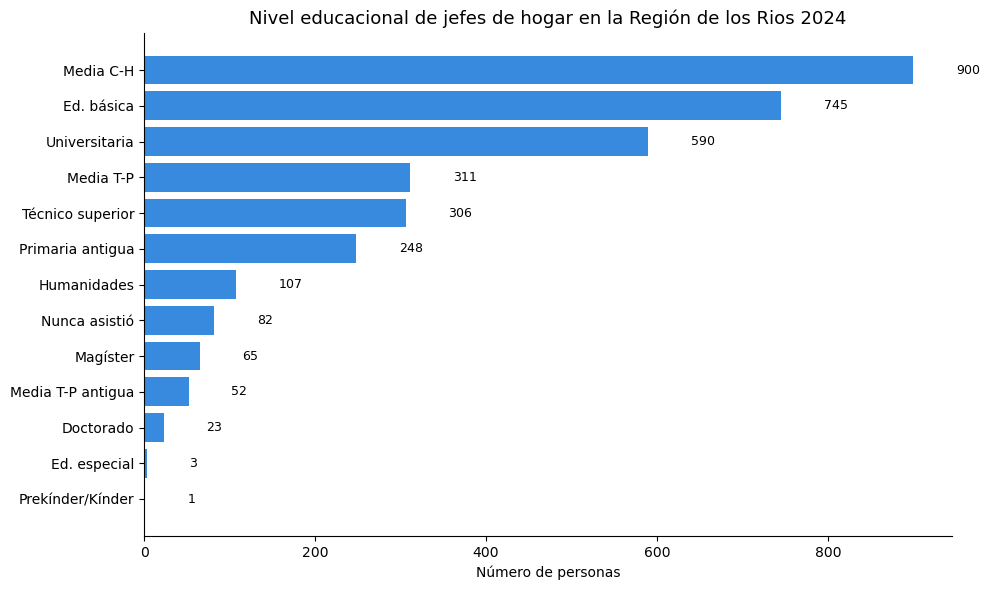

Total jefes de hogar: 3,433


In [12]:
# Graficar
fig, ax = plt.subplots(figsize=(10, 6)) # tamaño pers

bars = ax.barh(conteo.index, conteo.values, color="#378ADD")

for bar, valor in zip(bars, conteo.values):
    ax.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{valor:,}", va="center", fontsize=9
    )
ax.set_title("Nivel educacional de jefes de hogar en la Región de los Rios 2024", fontsize=13)
ax.set_xlabel("Número de personas")
ax.set_ylabel("")
ax.spines["top"].set_visible(False) # borra bordes
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Total jefes de hogar: {len(df_jefes):,}")